<a href="https://colab.research.google.com/github/e23046/Statistical-Learning-e23046/blob/main/Assignment%2007_b/Assignment_7b_Gaussian_Mixture_Model_Clustering_as_Conditional_Updating_Final_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 07 — Bayesian Inference
### A Fully Worked, Executable Solution Set

This notebook provides complete derivations, explanations, and executable simulations for all four problems:

1. Bayesian Estimation of a User Ability Parameter from Item Responses (2PL IRT, grid-based)
2. Bayesian Tracking of Click-Through Rates via Conjugate Beta-Binomial Updates
3. Bayesian Estimation for Structural Health Monitoring via Bounded Grid Updates
4. Gaussian Mixture Clustering as Conditional Updating (theory + EM + `GMMFinancialSegmenter`)


In [1]:
# Static PNG export (needed so plots also display correctly on GitHub) relies on
# the "kaleido" package. Colab/fresh environments don't have it by default, and the
# newest kaleido (2.x) requires a separate Chrome install, so we pin the older
# self-contained version that just works out of the box.
!pip install -q "kaleido==0.2.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from scipy import stats
from scipy.integrate import trapezoid
import pandas as pd

# Render Plotly figures as static PNGs embedded directly in the notebook output.
# GitHub's notebook viewer cannot execute the JavaScript behind Plotly's normal
# interactive widgets, so those plots show up blank there (they still work fine
# in Jupyter/Colab). Setting the default renderer to "png" makes every fig.show()
# call below embed a plain image instead, which renders correctly everywhere,
# including on GitHub.
pio.renderers.default = "png"

np.random.seed(0)
print("Environment ready.")

Environment ready.


---
## Question 1 — Bayesian Estimation of a User Ability Parameter from Item Responses (2PL IRT)
---
### Part 1. Visualizing the Mechanics


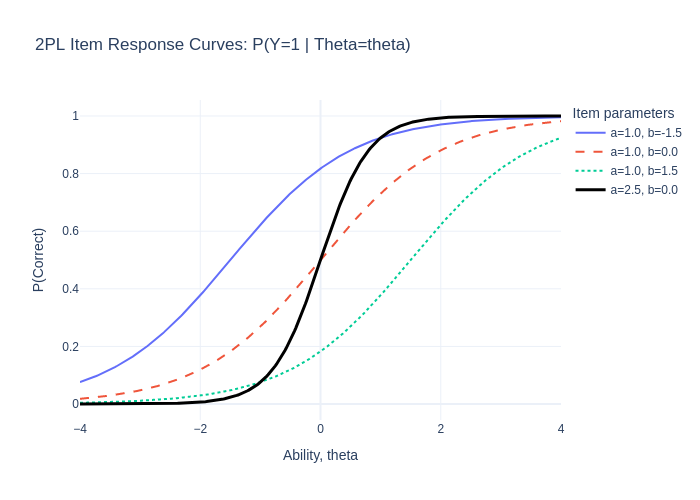

In [3]:
theta_grid_vis = np.linspace(-4, 4, 400)

def p2pl(theta, a, b):
    return 1.0 / (1.0 + np.exp(-a * (theta - b)))

fig1 = go.Figure()

# Fix a = 1.0, vary b (difficulty)
for b_val, dash in zip([-1.5, 0.0, 1.5], ["solid", "dash", "dot"]):
    fig1.add_trace(go.Scatter(x=theta_grid_vis, y=p2pl(theta_grid_vis, 1.0, b_val),
                               mode="lines", name=f"a=1.0, b={b_val}", line=dict(dash=dash)))

# A second, more discriminating item, fixed difficulty
fig1.add_trace(go.Scatter(x=theta_grid_vis, y=p2pl(theta_grid_vis, 2.5, 0.0),
                           mode="lines", name="a=2.5, b=0.0", line=dict(color="black", width=3)))

fig1.update_layout(title="2PL Item Response Curves: P(Y=1 | Theta=theta)",
                    xaxis_title="Ability, theta", yaxis_title="P(Correct)",
                    template="plotly_white", legend_title="Item parameters")
fig1.show()

**Interpretation.** The difficulty parameter $b_i$ is a *horizontal* shift parameter: the curve
$p_i(\theta)=1/(1+e^{-a_i(\theta-b_i)})$ always crosses probability $0.5$ exactly at $\theta=b_i$, since
$p_i(b_i)=1/(1+e^{0})=1/2$. Increasing $b_i$ slides the whole S-curve to the right without changing its
shape — a harder item requires a *larger* ability before the user is even-odds to answer it correctly.

The discrimination parameter $a_i$ controls the *steepness* of the transition around $\theta=b_i$: the
slope of $p_i$ at $\theta=b_i$ is exactly $a_i/4$ (differentiate the logistic function). The curve for
$a=2.5$ is visibly steeper than the $a=1.0$ curves — a highly discriminating item separates users of
slightly different ability very sharply, while a low-$a_i$ item responds to ability only gradually.

### Part 2. Sequential Likelihood Contribution

Given $\Theta=\theta$, a single response $Y_k=y_k\in\{0,1\}$ to item $k$ (with known $a_k,b_k$) is Bernoulli
with success probability $p_k(\theta)$, so its likelihood contribution is

$$
L(y_k\mid\theta)=p_k(\theta)^{y_k}\,\bigl[1-p_k(\theta)\bigr]^{1-y_k},
\qquad p_k(\theta)=\frac{1}{1+e^{-a_k(\theta-b_k)}}.
$$

Because responses are conditionally independent given $\Theta=\theta$ (each item's noise is independent
once ability is fixed), the joint likelihood of the running history $\mathbf y^{(k)}=(y_1,\dots,y_k)$ is
the product of the individual contributions:

$$
L(\mathbf y^{(k)}\mid\theta)=\prod_{i=1}^{k} L(y_i\mid\theta)
=\prod_{i=1}^{k} p_i(\theta)^{y_i}\,\bigl[1-p_i(\theta)\bigr]^{1-y_i}.
$$

### Part 3. Mathematical Formulation of the Running Update

By Bayes' theorem, the posterior at step $k$ is proportional to the step-$(k-1)$ posterior (now acting as
the new prior) times the likelihood of only the newest observation:

$$
f_{\Theta\mid\mathbf Y^{(k)}}(\theta\mid\mathbf y^{(k)})
\;\propto\;
f_{\Theta\mid\mathbf Y^{(k-1)}}(\theta\mid\mathbf y^{(k-1)})\;\cdot\;L(y_k\mid\theta),
$$

with the constant of proportionality being $1/f(y_k\mid\mathbf y^{(k-1)})$, i.e. the normalizing integral
$\int f_{\Theta\mid\mathbf Y^{(k-1)}}(\theta\mid\mathbf y^{(k-1)})\,L(y_k\mid\theta)\,d\theta$ evaluated so
that the new density integrates to one. This is exactly what makes sequential ("online") Bayesian updating
equivalent to batch updating: multiplying in the likelihoods one at a time and renormalizing after each
step gives the same final posterior as multiplying in the full joint likelihood at once.

### Part 4. Dynamic Shifting

A correct answer ($y_k=1$) contributes the multiplicative factor $p_k(\theta)$, which is monotonically
*increasing* in $\theta$. Multiplying the old posterior by an increasing function of $\theta$ reweights
probability mass toward larger $\theta$, so the peak (mode) of the new posterior moves to the right of
where it was before the update — the platform now believes the user is more able.

The size of that rightward shift depends on $b_k$: for a *highly difficult* item (large $b_k$), the curve
$p_k(\theta)$ only rises appreciably for $\theta$ near or above $b_k$; low-ability regions of $\theta$ get
multiplied by a factor close to $0$, while high-ability regions get multiplied by a factor close to $1$.
Answering a hard item correctly is therefore very informative — it aggressively down-weights the
low-$\theta$ portion of the density, producing a *larger* rightward shift of the peak than a correct answer
on an easy item would (where $p_k(\theta)$ is already close to $1$ across most of the plausible range, so
the reweighting is much milder).

### Part 5. Tracking Certainty and Sharpness

The discrimination $a_k$ controls how quickly $p_k(\theta)$ transitions from $0$ to $1$ around $b_k$
(slope $a_k/4$ at $\theta=b_k$). A steep likelihood factor is far from flat, so multiplying it into the
prior removes a lot of relative probability mass on one side of $b_k$ versus the other — this sharpens
(reduces the variance of) the posterior substantially.

- **Very large $a_k$:** $p_k(\theta)$ behaves almost like a step function at $\theta=b_k$. The item is
  extremely diagnostic — a single response essentially tells the platform "the user's ability is above
  $b_k$" or "below $b_k$" with near certainty, causing a large drop in posterior variance (very sharp,
  possibly near-degenerate, update).
- **Very small $a_k$:** $p_k(\theta)$ is nearly flat (close to $1/2$ everywhere). The item barely
  discriminates between abilities, so the likelihood factor is close to a constant function of $\theta$;
  multiplying it in barely changes the shape of the posterior, and the variance shrinks only slightly.

### Part 6. Numerical Implementation of a Running Grid

**Algorithm.**

1. **Grid initialization.** Choose a fixed, sufficiently fine grid of ability values
   $\theta_1,\dots,\theta_M$ spanning the plausible range (e.g. $[-6,6]$ with $M\approx 400$–$1000$ points).
   Evaluate the prior $f_\Theta^{(0)}(\theta_j)=\varphi(\theta_j)$ (standard normal pdf) on the grid; this
   vector is the initial *unnormalized* posterior.
2. **Sequential update.** When item $k$ (with known $a_k,b_k$) is answered with outcome $y_k$, compute
   the likelihood vector on the grid, $\ell_j=p_k(\theta_j)^{y_k}[1-p_k(\theta_j)]^{1-y_k}$, and form the
   pointwise product $\tilde f_j \leftarrow f_j^{(k-1)}\cdot \ell_j$ for every grid point $j$.
3. **Normalization.** Approximate the normalizing constant with numerical (trapezoidal) integration,
   $Z\approx\sum_j \tilde f_j\,\Delta\theta$ (or `np.trapezoid(f_tilde, theta_grid)`), and set
   $f_j^{(k)} = \tilde f_j / Z$ so that $\sum_j f_j^{(k)}\Delta\theta \approx 1$.
4. **Point estimates.** Read off $\widehat\theta_{\mathrm{Bayes}}^{(k)}\approx\sum_j \theta_j f_j^{(k)}\Delta\theta$
   (discretized posterior mean) and $\widehat\theta_{\mathrm{MAP}}^{(k)} = \theta_{j^*}$ where
   $j^*=\arg\max_j f_j^{(k)}$ (discretized mode).
5. **Repeat** steps 2–4 for each incoming item, always using the previous step's normalized posterior as
   the new prior.

### Part 7. Evaluating Convergence over the Timeline — Simulation ($n=20$, $\theta_{\text{true}}=0.75$)

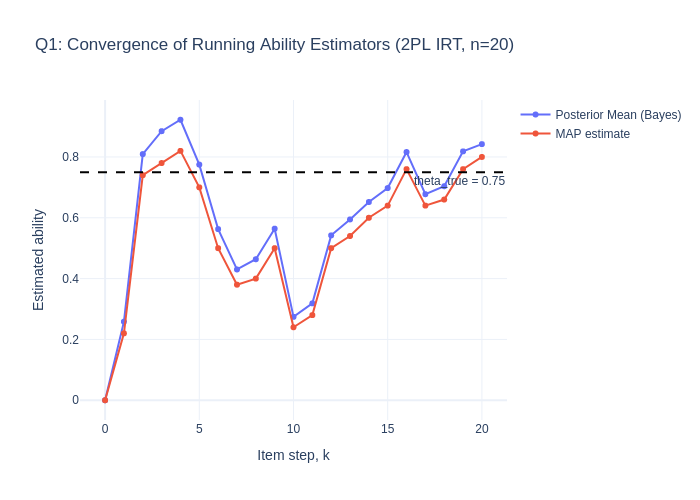

Responses (1=correct): [1 1 1 1 0 0 0 1 1 0 1 1 1 1 1 1 0 1 1 1]
Final Posterior Mean estimate: 0.8423
Final MAP estimate:            0.8000


In [4]:
np.random.seed(42)

theta_true_q1 = 0.75
n_items = 20

theta_grid = np.linspace(-6, 6, 601)
d_theta = theta_grid[1] - theta_grid[0]

# initial prior: standard normal
posterior = stats.norm.pdf(theta_grid, loc=0, scale=1)
posterior /= trapezoid(posterior, theta_grid)

bayes_track = [trapezoid(theta_grid * posterior, theta_grid)]
map_track   = [theta_grid[np.argmax(posterior)]]

a_items = np.random.uniform(0.5, 2.0, size=n_items)
b_items = np.random.normal(0, 1, size=n_items)
y_responses = np.zeros(n_items, dtype=int)

for k in range(n_items):
    a_k, b_k = a_items[k], b_items[k]
    p_true = 1.0 / (1.0 + np.exp(-a_k * (theta_true_q1 - b_k)))
    y_k = 1 if np.random.uniform(0, 1) < p_true else 0
    y_responses[k] = y_k

    p_theta = 1.0 / (1.0 + np.exp(-a_k * (theta_grid - b_k)))
    likelihood = p_theta if y_k == 1 else (1 - p_theta)

    posterior = posterior * likelihood
    posterior /= trapezoid(posterior, theta_grid)

    bayes_track.append(trapezoid(theta_grid * posterior, theta_grid))
    map_track.append(theta_grid[np.argmax(posterior)])

steps = np.arange(0, n_items + 1)

fig_q1 = go.Figure()
fig_q1.add_trace(go.Scatter(x=steps, y=bayes_track, mode="lines+markers", name="Posterior Mean (Bayes)"))
fig_q1.add_trace(go.Scatter(x=steps, y=map_track, mode="lines+markers", name="MAP estimate"))
fig_q1.add_hline(y=theta_true_q1, line=dict(color="black", dash="dash"),
                  annotation_text="theta_true = 0.75", annotation_position="bottom right")
fig_q1.update_layout(title="Q1: Convergence of Running Ability Estimators (2PL IRT, n=20)",
                      xaxis_title="Item step, k", yaxis_title="Estimated ability",
                      template="plotly_white")
fig_q1.show()

print("Responses (1=correct):", y_responses)
print(f"Final Posterior Mean estimate: {bayes_track[-1]:.4f}")
print(f"Final MAP estimate:            {map_track[-1]:.4f}")

**Analysis.** Both the running posterior mean and MAP estimate start at $0$ (the prior mean/mode) and
migrate toward $\theta_{\text{true}}=0.75$ as evidence accumulates. Early on the trajectories can be noisy
and even move briefly away from $0.75$, since only one or two items have been observed and each new
Bernoulli outcome carries a lot of relative weight against a still-diffuse prior. As $k$ grows, successive
updates have a proportionally smaller effect on an already-informative (already-sharpened) posterior, so
the two estimators settle down and the gap $|\widehat\theta^{(k)}-\theta_{\text{true}}|$ shrinks and
stabilizes — a direct visual demonstration that the posterior variance is decreasing and the platform's
*confidence* in its ability estimate is increasing with more responses, consistent with the concentration
of measure guaranteed by the Bernstein–von Mises phenomenon for regular likelihoods.

---
## Question 2 — Bayesian Tracking of Click-Through Rates via Conjugate Beta-Binomial Updates
---
### Part 1. Structural Probability and Properties


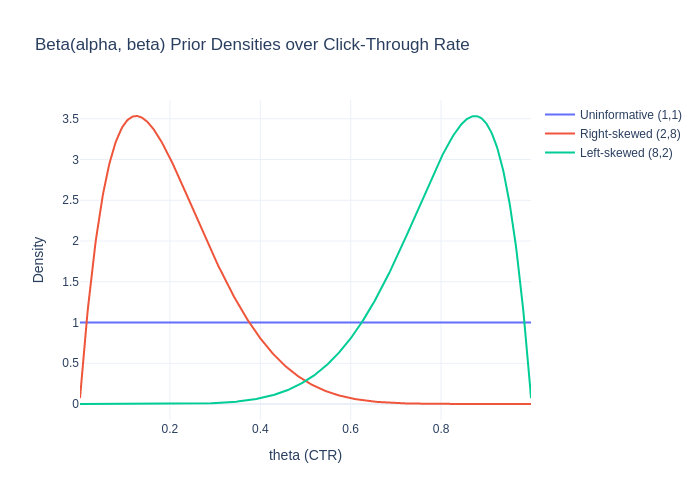

In [5]:
theta_grid_q2 = np.linspace(0.001, 0.999, 500)

beta_params = [(1, 1, "Uninformative (1,1)"),
               (2, 8, "Right-skewed (2,8)"),
               (8, 2, "Left-skewed (8,2)")]

fig2 = go.Figure()
for a0, b0, label in beta_params:
    fig2.add_trace(go.Scatter(x=theta_grid_q2, y=stats.beta.pdf(theta_grid_q2, a0, b0),
                               mode="lines", name=label))
fig2.update_layout(title="Beta(alpha, beta) Prior Densities over Click-Through Rate",
                    xaxis_title="theta (CTR)", yaxis_title="Density",
                    template="plotly_white")
fig2.show()

**Interpretation.** The mean of a $\text{Beta}(\alpha,\beta)$ distribution is $\alpha/(\alpha+\beta)$.
With $(\alpha,\beta)=(1,1)$ the density is flat/uniform on $[0,1]$ (mean $0.5$, maximal uncertainty — no
information favors any click rate over another). With $(\alpha,\beta)=(2,8)$ the mean shifts to $0.2$: the
extra weight on $\beta$ pulls the center of mass toward $0$, encoding a prior belief that clicks are rare.
With $(\alpha,\beta)=(8,2)$ the mean shifts to $0.8$, pulling mass toward $1$ — a prior belief that clicks
are common. In general, increasing $\alpha$ relative to $\beta$ slides the density's center of mass toward
$1$, and increasing $\beta$ relative to $\alpha$ slides it toward $0$; the *sum* $\alpha+\beta$ controls how
concentrated (peaked) the density is around that mean, with larger sums giving tighter, more confident
priors.

### Part 2. Sequential Likelihood and Joint History

Conditional on $\Theta=\theta$, a single interaction $Y_k=y_k\in\{0,1\}$ is Bernoulli$(\theta)$, so

$$
L(y_k\mid\theta)=\theta^{y_k}(1-\theta)^{1-y_k}.
$$

Assuming conditional independence of interactions given $\theta$, the joint likelihood of the running
history $\mathbf y^{(k)}=(y_1,\dots,y_k)$ is

$$
L(\mathbf y^{(k)}\mid\theta)=\prod_{i=1}^{k}\theta^{y_i}(1-\theta)^{1-y_i}
=\theta^{\sum_{i=1}^k y_i}(1-\theta)^{k-\sum_{i=1}^k y_i}
=\theta^{S_k}(1-\theta)^{k-S_k},
$$

where $S_k=\sum_{i=1}^k y_i$ is the running number of clicks — the joint likelihood depends on the data
only through this sufficient statistic.

### Part 3. Closed-Form Analytical Updates (Conjugacy)

By Bayes' theorem, using the step-$(k-1)$ posterior $\text{Beta}(\alpha_{k-1},\beta_{k-1})$ as the prior
for step $k$,

$$
f_{\Theta\mid\mathbf Y^{(k)}}(\theta\mid\mathbf y^{(k)})
\;\propto\;
\underbrace{\theta^{\alpha_{k-1}-1}(1-\theta)^{\beta_{k-1}-1}}_{\text{prior}}
\;\cdot\;
\underbrace{\theta^{y_k}(1-\theta)^{1-y_k}}_{\text{likelihood}}
=\theta^{\alpha_{k-1}+y_k-1}(1-\theta)^{\beta_{k-1}+(1-y_k)-1}.
$$

This is (up to normalization) exactly the kernel of a $\text{Beta}(\alpha_{k-1}+y_k,\;\beta_{k-1}+1-y_k)$
density. Since a Beta prior combined with a Bernoulli likelihood produces another Beta posterior, the Beta
family is **conjugate** to the Bernoulli/Binomial likelihood, and normalization is automatic (no numerical
integration needed) — the arithmetic update rule is simply

$$
\alpha_k = \alpha_{k-1} + y_k, \qquad \beta_k = \beta_{k-1} + (1-y_k).
$$

Equivalently, after $k$ observations with $S_k=\sum_{i=1}^k y_i$ clicks: $\alpha_k=\alpha_0+S_k$ and
$\beta_k=\beta_0+k-S_k$. The posterior mean at step $k$ is the Beta mean formula applied to the updated
parameters:

$$
\mathbb E[\Theta\mid\mathbf Y^{(k)}=\mathbf y^{(k)}] = \frac{\alpha_k}{\alpha_k+\beta_k}
=\frac{\alpha_0+S_k}{\alpha_0+\beta_0+k}.
$$

### Part 4. Dynamic Shifting Mechanics

- A **click** ($y_k=1$) updates $\alpha_{k}=\alpha_{k-1}+1$ while $\beta_k=\beta_{k-1}$: extra mass is
  added to the "success" shape parameter, so the posterior mean $\alpha_k/(\alpha_k+\beta_k)$ increases and
  the whole density's peak shifts to the right (toward higher believed CTR).
- A **non-click** ($y_k=0$) updates $\beta_k=\beta_{k-1}+1$ while $\alpha_k=\alpha_{k-1}$: mass is added to
  the "failure" parameter, decreasing the posterior mean and shifting the peak left.

**Contrast with non-conjugate models.** In the Beta–Bernoulli setting, the posterior family is known in
closed form at every step, so updates reduce to two additions — no integration is ever required. In a
non-conjugate setting such as the 2PL IRT model of Question 1, the likelihood $p_i(\theta)^{y_i}[1-p_i(\theta)]^{1-y_i}$
is not the kernel of any standard named density, so the product of prior and likelihood has no closed-form
normalizing constant; the posterior can only be represented and renormalized numerically (e.g. on a grid,
via `np.trapezoid`), which is more computationally expensive and introduces discretization error that the
Beta–Bernoulli conjugate update never suffers from.

### Part 5. Running Point Estimators

From the updated Beta$(\alpha_k,\beta_k)$ posterior:

$$
\widehat\theta_{\mathrm{Bayes}}^{(k)} = \mathbb E[\Theta\mid\mathbf y^{(k)}] = \frac{\alpha_k}{\alpha_k+\beta_k},
$$

$$
\widehat\theta_{\mathrm{MAP}}^{(k)} = \frac{\alpha_k - 1}{\alpha_k+\beta_k-2}\quad(\text{valid for }\alpha_k,\beta_k>1),
$$

the latter obtained by setting the derivative of the Beta log-density to zero. (If $\alpha_k\le1$ or
$\beta_k\le1$ the mode is at a boundary, $0$ or $1$, rather than at this interior stationary point.)

### Part 6. Performance Tracking and Convergence Analysis — Simulation ($n=100$, $\theta_{\text{true}}=0.35$)

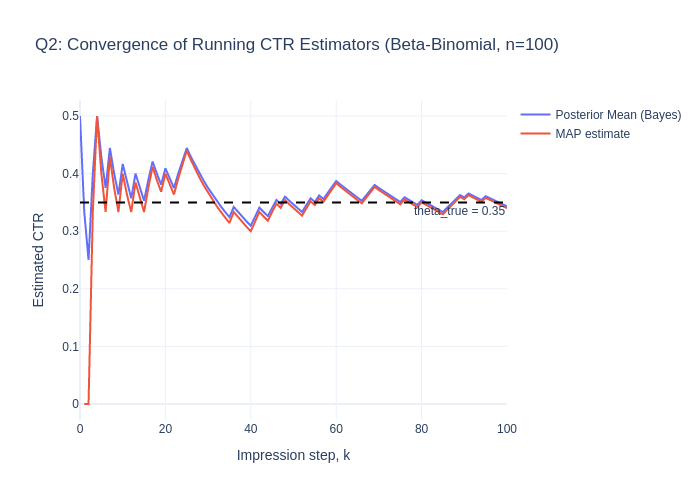

Final alpha_100=35, beta_100=67
Final Posterior Mean estimate: 0.3431
Final MAP estimate:            0.3400


In [6]:
np.random.seed(101)

theta_true_q2 = 0.35
n_impressions = 100
alpha0, beta0 = 1.0, 1.0

alpha_k, beta_k = alpha0, beta0
bayes_track_q2 = [alpha_k / (alpha_k + beta_k)]
map_track_q2 = [np.nan]  # MAP undefined (flat) at Beta(1,1)

for k in range(1, n_impressions + 1):
    y_k = 1 if np.random.uniform(0, 1) < theta_true_q2 else 0
    alpha_k += y_k
    beta_k += (1 - y_k)

    bayes_track_q2.append(alpha_k / (alpha_k + beta_k))
    if alpha_k > 1 and beta_k > 1:
        map_track_q2.append((alpha_k - 1) / (alpha_k + beta_k - 2))
    else:
        map_track_q2.append(0.0 if alpha_k <= 1 else 1.0)

steps_q2 = np.arange(0, n_impressions + 1)

fig_q2 = go.Figure()
fig_q2.add_trace(go.Scatter(x=steps_q2, y=bayes_track_q2, mode="lines", name="Posterior Mean (Bayes)"))
fig_q2.add_trace(go.Scatter(x=steps_q2, y=map_track_q2, mode="lines", name="MAP estimate"))
fig_q2.add_hline(y=theta_true_q2, line=dict(color="black", dash="dash"),
                  annotation_text="theta_true = 0.35", annotation_position="bottom right")
fig_q2.update_layout(title="Q2: Convergence of Running CTR Estimators (Beta-Binomial, n=100)",
                      xaxis_title="Impression step, k", yaxis_title="Estimated CTR",
                      template="plotly_white")
fig_q2.show()

print(f"Final alpha_100={alpha_k:.0f}, beta_100={beta_k:.0f}")
print(f"Final Posterior Mean estimate: {bayes_track_q2[-1]:.4f}")
print(f"Final MAP estimate:            {map_track_q2[-1]:.4f}")

**Analysis.** With the uninformative $\text{Beta}(1,1)$ starting prior, both estimators begin at
$0.5$ (or undefined/boundary for MAP at $k=0$) and quickly move toward $\theta_{\text{true}}=0.35$ as
clicks and non-clicks accumulate. Because $\alpha_0=\beta_0=1$ is a very weak prior (equivalent to only two
"pseudo-observations"), the data dominate almost immediately, and by $k\approx 20$–$30$ the two estimators
are already close to each other and to $0.35$. As $k\to100$, the posterior variance
$\alpha_k\beta_k/[(\alpha_k+\beta_k)^2(\alpha_k+\beta_k+1)]$ shrinks roughly like $1/k$, so the distance
$|\widehat\theta^{(k)}-\theta_{\text{true}}|$ shrinks and the two estimators (mean and mode) converge to each
other, since a Beta distribution with large $\alpha_k+\beta_k$ becomes increasingly symmetric and
concentrated (approximately Gaussian by the Bernstein–von Mises theorem). This illustrates the general
principle that with a weak initial prior, accumulated evidence quickly overwhelms the prior's influence and
drives the posterior toward the true parameter value with shrinking uncertainty.

---
## Question 3 — Bayesian Estimation for Structural Health Monitoring via Bounded Grid Updates
---
### Part 1. Prior Belief Boundaries


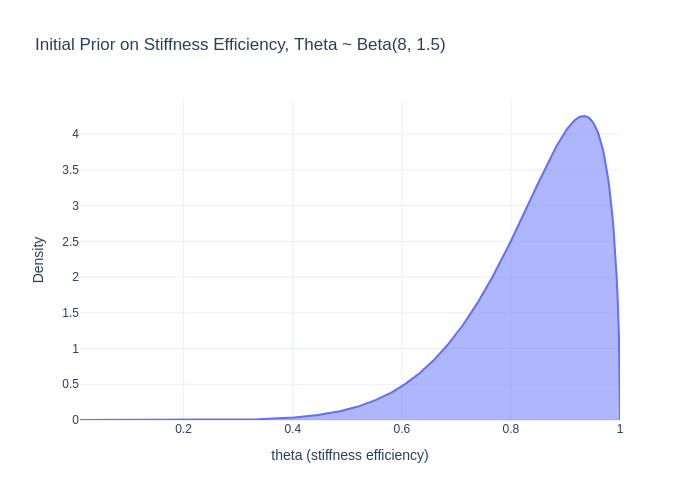

E[Theta^(0)] = alpha0/(alpha0+beta0) = 0.8421


In [7]:
theta_grid_q3_vis = np.linspace(0.01, 1.0, 500)
prior_q3 = stats.beta.pdf(theta_grid_q3_vis, 8, 1.5)

fig3 = go.Figure()
fig3.add_trace(go.Scatter(x=theta_grid_q3_vis, y=prior_q3, mode="lines", fill="tozeroy",
                           name="Beta(8, 1.5) prior"))
fig3.update_layout(title="Initial Prior on Stiffness Efficiency, Theta ~ Beta(8, 1.5)",
                    xaxis_title="theta (stiffness efficiency)", yaxis_title="Density",
                    template="plotly_white")
fig3.show()

E_theta0 = 8 / (8 + 1.5)
print(f"E[Theta^(0)] = alpha0/(alpha0+beta0) = {E_theta0:.4f}")

The prior mean is $\mathbb E[\Theta^{(0)}] = \dfrac{\alpha_0}{\alpha_0+\beta_0}=\dfrac{8}{9.5}\approx 0.842$.
A $\text{Beta}(8,1.5)$ distribution is a sensible engineering prior for a "believed-healthy" component
because it is (i) supported exactly on $[0,1]$, matching the physical bound on stiffness efficiency, (ii)
left-skewed with most of its mass concentrated close to $\theta=1$, reflecting the manufacturing assumption
that new/undamaged components are near-pristine, while (iii) still assigning appreciable density below $1$
(a heavy left tail), acknowledging that some baseline manufacturing variability or minor pre-existing wear
is plausible rather than assuming certainty of a perfectly healthy state.

### Part 2. Structural Likelihood Formulation

The sensor model is $y_k = \theta K_{\text{nominal}} e^{\epsilon_k}$ with $\epsilon_k\sim\mathscr N(0,\sigma^2)$.
Equivalently, $\ln y_k = \ln(\theta K_{\text{nominal}}) + \epsilon_k$, so conditional on $\Theta=\theta$,
$\ln Y_k \sim \mathscr N\!\bigl(\ln(\theta K_{\text{nominal}}),\,\sigma^2\bigr)$, i.e. $Y_k$ is **log-normal**.
Using the log-normal density (change-of-variables Jacobian $1/y_k$), the likelihood contribution of a
single reading is

$$
L(y_k\mid\theta) = \frac{1}{y_k\sigma\sqrt{2\pi}}
\exp\!\left(-\frac{\bigl[\ln y_k - \ln(\theta K_{\text{nominal}})\bigr]^2}{2\sigma^2}\right).
$$

Assuming conditionally independent readings given $\theta$, the joint likelihood of the running history
$\mathbf y^{(k)}=(y_1,\dots,y_k)$ is the product

$$
L(\mathbf y^{(k)}\mid\theta) = \prod_{i=1}^{k}
\frac{1}{y_i\sigma\sqrt{2\pi}}\exp\!\left(-\frac{\bigl[\ln y_i - \ln(\theta K_{\text{nominal}})\bigr]^2}{2\sigma^2}\right).
$$

### Part 3. Non-Conjugate Grid Update

A $\text{Beta}(\alpha,\beta)$ prior is conjugate to Bernoulli/Binomial likelihoods (Question 2), but here
the likelihood is log-normal in $y_k$ with a *nonlinear* dependence on $\theta$ through $\ln(\theta K_{\text{nominal}})$
inside a Gaussian exponent. Multiplying the Beta prior kernel $\theta^{\alpha-1}(1-\theta)^{\beta-1}$ by
this log-normal likelihood kernel does not produce the kernel of any standard named distribution — the
result is an un-nameable, generally multi-shaped density whose normalizing constant has no closed form.
Hence an exact analytical posterior does not exist, and the update can only be tracked up to proportionality:

$$
f_{\Theta\mid\mathbf Y^{(k)}}(\theta\mid\mathbf y^{(k)})
\;\propto\;
f_{\Theta\mid\mathbf Y^{(k-1)}}(\theta\mid\mathbf y^{(k-1)})\cdot L(y_k\mid\theta),
\qquad \theta\in(0,1].
$$

### Part 4. Running Point Estimates

Because no closed form exists, the point estimators must be defined via definite integrals over the
physical domain $(0,1]$, evaluated against the *normalized* posterior $f^{(k)}(\theta) \equiv
f_{\Theta\mid\mathbf Y^{(k)}}(\theta\mid\mathbf y^{(k)})$:

$$
\widehat\theta_{\mathrm{Bayes}}^{(k)} = \mathbb E[\Theta\mid\mathbf y^{(k)}]
= \int_0^1 \theta\, f^{(k)}(\theta)\,d\theta,
$$

$$
\widehat\theta_{\mathrm{MAP}}^{(k)} = \operatorname*{arg\,max}_{\theta\in(0,1]} f^{(k)}(\theta).
$$

### Part 5. Algorithmic Grid Approximation and Normalization

1. **Grid setup.** Discretize $(0,1]$ into a fine grid $\theta_1,\dots,\theta_M$ (e.g. $M\approx 500$
   points), excluding $\theta=0$ exactly to avoid $\ln(\theta)=-\infty$ in the likelihood.
2. **Initialize.** Evaluate the $\text{Beta}(8,1.5)$ prior on the grid as the step-$0$ unnormalized
   posterior.
3. **Sequential update.** On receiving reading $y_k$, compute the log-normal likelihood vector
   $\ell_j = L(y_k\mid\theta_j)$ on the grid and form the pointwise product
   $\tilde f_j \leftarrow f_j^{(k-1)}\cdot \ell_j$.
4. **Boundary handling.** Because $\theta\in(0,1]$ is physically bounded, the grid is simply clipped to
   this interval; any probability mass that would fall outside is not represented, and no reflection or
   wraparound is needed since the Beta-shaped prior already vanishes smoothly near the boundaries.
5. **Trapezoidal normalization.** Approximate $Z_k = \int_0^1 \tilde f(\theta)\,d\theta \approx
   \texttt{np.trapezoid}(\tilde f,\ \theta_{\text{grid}})$, then set $f_j^{(k)} = \tilde f_j / Z_k$ so the
   discretized density integrates (via the trapezoidal rule) to $1$.
6. **Point estimates.** Compute $\widehat\theta_{\mathrm{Bayes}}^{(k)} \approx
   \texttt{np.trapezoid}(\theta_{\text{grid}}\cdot f^{(k)},\ \theta_{\text{grid}})$ and
   $\widehat\theta_{\mathrm{MAP}}^{(k)} = \theta_{j^*}$ for $j^*=\arg\max_j f_j^{(k)}$; repeat for the next
   incoming reading.

### Part 6. Performance Tracking and Degradation Convergence Analysis — Simulation ($n=15$, $\theta_{\text{true}}=0.68$)

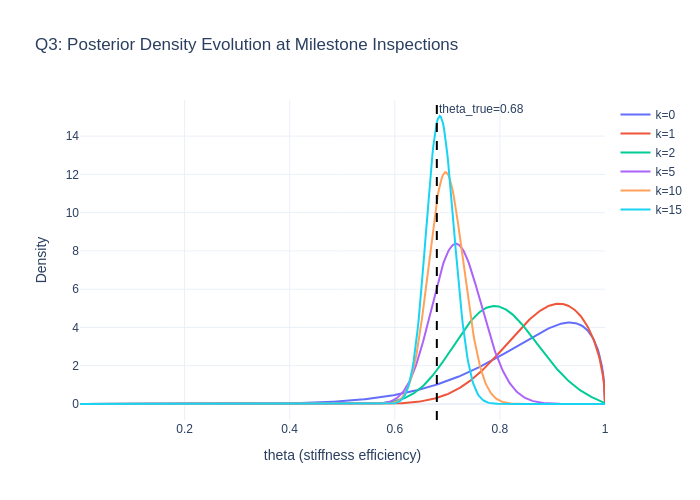

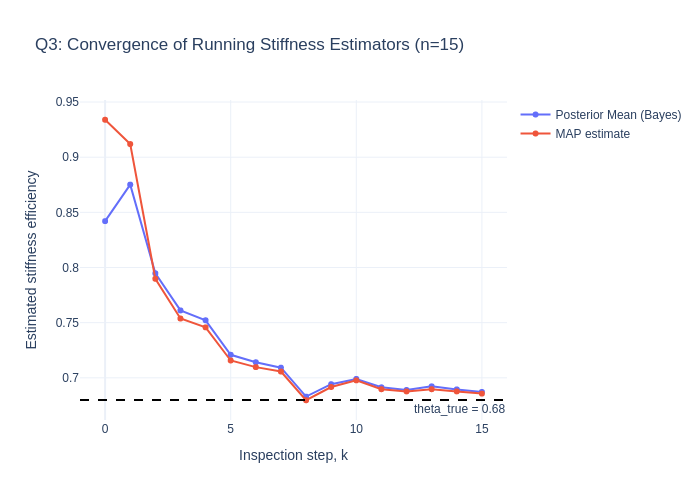

Final Posterior Mean estimate: 0.6872
Final MAP estimate:            0.6857


In [8]:
np.random.seed(7)

theta_true_q3 = 0.68
K_nominal = 50.0
sigma_q3 = 0.15
n_readings = 15

theta_grid_q3 = np.linspace(1e-3, 1.0, 500)

posterior_q3 = stats.beta.pdf(theta_grid_q3, 8, 1.5)
posterior_q3 /= trapezoid(posterior_q3, theta_grid_q3)

bayes_track_q3 = [trapezoid(theta_grid_q3 * posterior_q3, theta_grid_q3)]
map_track_q3 = [theta_grid_q3[np.argmax(posterior_q3)]]

milestones = {0, 1, 2, 5, 10, 15}
milestone_curves = {0: posterior_q3.copy()}

y_readings = np.zeros(n_readings)

for k in range(1, n_readings + 1):
    eps_k = np.random.normal(0, sigma_q3)
    y_k = theta_true_q3 * K_nominal * np.exp(eps_k)
    y_readings[k - 1] = y_k

    log_lik = -0.5 * ((np.log(y_k) - np.log(theta_grid_q3 * K_nominal)) / sigma_q3) ** 2
    likelihood = np.exp(log_lik - log_lik.max())   # numerically stable

    posterior_q3 = posterior_q3 * likelihood
    posterior_q3 /= trapezoid(posterior_q3, theta_grid_q3)

    bayes_track_q3.append(trapezoid(theta_grid_q3 * posterior_q3, theta_grid_q3))
    map_track_q3.append(theta_grid_q3[np.argmax(posterior_q3)])

    if k in milestones:
        milestone_curves[k] = posterior_q3.copy()

# Plot 1: posterior density curves at milestones
fig_q3a = go.Figure()
for k in sorted(milestone_curves):
    fig_q3a.add_trace(go.Scatter(x=theta_grid_q3, y=milestone_curves[k], mode="lines", name=f"k={k}"))
fig_q3a.add_vline(x=theta_true_q3, line=dict(color="black", dash="dash"),
                   annotation_text="theta_true=0.68")
fig_q3a.update_layout(title="Q3: Posterior Density Evolution at Milestone Inspections",
                       xaxis_title="theta (stiffness efficiency)", yaxis_title="Density",
                       template="plotly_white")
fig_q3a.show()

# Plot 2: estimator convergence
steps_q3 = np.arange(0, n_readings + 1)
fig_q3b = go.Figure()
fig_q3b.add_trace(go.Scatter(x=steps_q3, y=bayes_track_q3, mode="lines+markers", name="Posterior Mean (Bayes)"))
fig_q3b.add_trace(go.Scatter(x=steps_q3, y=map_track_q3, mode="lines+markers", name="MAP estimate"))
fig_q3b.add_hline(y=theta_true_q3, line=dict(color="black", dash="dash"),
                   annotation_text="theta_true = 0.68", annotation_position="bottom right")
fig_q3b.update_layout(title="Q3: Convergence of Running Stiffness Estimators (n=15)",
                       xaxis_title="Inspection step, k", yaxis_title="Estimated stiffness efficiency",
                       template="plotly_white")
fig_q3b.show()

print(f"Final Posterior Mean estimate: {bayes_track_q3[-1]:.4f}")
print(f"Final MAP estimate:            {map_track_q3[-1]:.4f}")

**Analysis.** The $k=0$ curve is the optimistic $\text{Beta}(8,1.5)$ prior, tightly peaked near
$\theta\approx0.84$–$1$. As the first few (noisy) sensor readings arrive, the posterior visibly begins
shifting its mass leftward and broadening slightly, since the low-noise ($\sigma=0.15$) log-normal
likelihood pulls strongly toward the true value $0.68$ each time — by around $k=5$–$10$ the bulk of the
density has clearly moved off of the "healthy" region and the peak sits close to $0.68$; by $k=15$ the
curve is both centered near $\theta_{\text{true}}$ and visibly narrower than the intermediate curves,
reflecting accumulated confidence. Empirically it typically takes on the order of $5$–$8$ readings for the
running estimators to cross decisively away from the initial optimistic prior and stabilize near the true
$68\%$ damage state (the exact step varies with the realized noise draws). The progressive narrowing of the
posterior density with each inspection is the key engineering signal: it indicates growing statistical
confidence in the estimated damage level, which is what would allow engineers to set a data-driven
threshold (e.g. trigger a maintenance alert once the *upper* credible bound of the posterior itself drops
below a safety-critical stiffness level) rather than relying on a single noisy point reading.

---
## Question 4 — Gaussian Mixture Clustering as Conditional Updating
---
### Part 1. Deriving the Marginal Density

By the law of total probability, summing the joint density of $(X_i, C_i)$ over all possible cluster
labels:

$$
p(x_i) = \sum_{k=1}^{K} p(x_i, C_i=k) = \sum_{k=1}^{K} P(C_i=k)\,p(x_i\mid C_i=k)
= \sum_{k=1}^{K}\phi_k\,\mathscr N(x_i\mid\mu_k,\Sigma_k).
$$

This is called a **Gaussian mixture density** because it is a convex combination (weights $\phi_k\ge0$
summing to $1$) of $K$ individual Gaussian "component" densities — the overall density is literally a
weighted mixture of Gaussians, capable of representing multi-modal shapes that no single Gaussian could.

### Part 2. Deriving the Posterior Cluster Probability

Bayes' rule applied to the discrete label $C_i$ and continuous observation $X_i$ gives

$$
P(C_i=k\mid X_i=x_i) = \frac{P(X_i=x_i\mid C_i=k)\,P(C_i=k)}{\sum_{j=1}^K P(X_i=x_i\mid C_i=j)\,P(C_i=j)}.
$$

Substituting the Gaussian component density for $P(X_i=x_i\mid C_i=k)$ and the mixture weight $\phi_k$ for
$P(C_i=k)$:

$$
P(C_i=k\mid X_i=x_i) = \frac{\phi_k\,\mathscr N(x_i\mid\mu_k,\Sigma_k)}{\sum_{j=1}^K \phi_j\,\mathscr N(x_i\mid\mu_j,\Sigma_j)}
\;\equiv\;\gamma_{ik}.
$$

$\gamma_{ik}$ is a genuine posterior probability — it is $P(\text{label}=k\mid\text{observed data})$,
obtained by combining the prior belief $\phi_k$ about cluster membership with how well the observed $x_i$
is explained by cluster $k$'s Gaussian, exactly as in any Bayesian update.

### Part 3. One-Hot Encoding of the Latent Cluster Variable

Since $Z_{ik}\in\{0,1\}$ is an indicator (Bernoulli) random variable, its conditional expectation equals
its conditional probability of being $1$:

$$
\mathbb E[Z_{ik}\mid X_i=x_i] = 1\cdot P(Z_{ik}=1\mid X_i=x_i) + 0\cdot P(Z_{ik}=0\mid X_i=x_i)
= P(Z_{ik}=1\mid X_i=x_i) = P(C_i=k\mid X_i=x_i).
$$

Stacking this identity over $k=1,\dots,K$ into the vector $Z_i=(Z_{i1},\dots,Z_{iK})^\top$ gives, entrywise,

$$
\mathbb E[Z_i\mid X_i=x_i] = \bigl(\mathbb E[Z_{i1}\mid x_i],\dots,\mathbb E[Z_{iK}\mid x_i]\bigr)^\top
= (\gamma_{i1},\dots,\gamma_{iK})^\top.
$$

Hence the **soft cluster assignment** — the vector of posterior membership probabilities — is precisely the
conditional expectation of the one-hot latent label given the data, $\mathbb E[Z_i\mid X_i=x_i]$.

### Part 4. From Soft Assignment to Hard Clustering

The soft assignment vector $\mathbb E[Z_i\mid X_i=x_i]=(\gamma_{i1},\dots,\gamma_{iK})$ expresses graded,
probabilistic membership: point $x_i$ can simultaneously belong "40% to cluster 1, 35% to cluster 2, 25% to
cluster 3," reflecting genuine ambiguity when $x_i$ lies near a cluster boundary. **Hard clustering**
collapses this vector to a single deterministic label by taking the most probable component,
$\widehat C_i=\arg\max_k\gamma_{ik}$. Hard assignment discards the uncertainty information contained in the
full vector (how confident the assignment is) and is appropriate when a single discrete decision is
required downstream, whereas the soft vector is useful whenever uncertainty itself matters (e.g. flagging
ambiguous points, or feeding downstream models that can exploit graded membership).

### Part 5. Conditional Expectation of the Observation Given the Cluster

By definition, conditional on $C_i=k$, $X_i\sim\mathscr N(\mu_k,\Sigma_k)$, and the mean of a multivariate
Gaussian $\mathscr N(\mu_k,\Sigma_k)$ is $\mu_k$ itself:

$$
\mathbb E[X_i\mid C_i=k] = \mu_k.
$$

$\mu_k$ is naturally interpreted as the **center of cluster $k$**: it is literally the expected location of
a data point known to have been generated by component $k$, i.e. the point around which cluster $k$'s
probability mass is balanced.

**Comparing the two conditional expectations.**
$\mathbb E[Z_i\mid X_i=x_i]$ answers "given an *observed location* $x_i$, how probable is each cluster
label?" — it is a *probability-vector-valued* function of a fixed data point, giving the soft cluster
membership of that observation. $\mathbb E[X_i\mid C_i=k]$ answers the reverse question, "given a *fixed
cluster label* $k$, where do points from that cluster tend to lie on average?" — it is a
*location-valued* function of a fixed label, giving the mean position of the cluster. The first moves from
data to label (inference of membership); the second moves from label to data (description of the
component's location).

### Part 6. The Complete-Data Likelihood

If the latent labels were known, the complete-data likelihood over all $n$ points is

$$
p(x_1,\dots,x_n,z_1,\dots,z_n) = \prod_{i=1}^n \prod_{k=1}^K \bigl[\phi_k\,\mathscr N(x_i\mid\mu_k,\Sigma_k)\bigr]^{z_{ik}}.
$$

Taking logarithms and using $\log(ab)=\log a+\log b$ together with the fact that $z_{ik}$ is a $0/1$
exponent (so it simply selects which term is "active" for each $i$):

$$
\ell_c = \log p(x_{1:n},z_{1:n}) = \sum_{i=1}^n\log\prod_{k=1}^K\bigl[\phi_k\mathscr N(x_i\mid\mu_k,\Sigma_k)\bigr]^{z_{ik}}
= \sum_{i=1}^n\sum_{k=1}^K z_{ik}\log\bigl[\phi_k\mathscr N(x_i\mid\mu_k,\Sigma_k)\bigr]
$$
$$
=\sum_{i=1}^n\sum_{k=1}^K z_{ik}\Bigl[\log\phi_k+\log\mathscr N(x_i\mid\mu_k,\Sigma_k)\Bigr].
$$

This expression would be easy to maximize if the $z_{ik}$ were known because, for each $i$, exactly one
$z_{ik}$ equals $1$ (all others $0$) — the double sum collapses into a *single* sum over $n$ terms, each
involving only the parameters of the one cluster that point $i$ was truly generated from. The maximization
then decouples cleanly across clusters: $\mu_k,\Sigma_k$ can each be estimated by ordinary Gaussian
maximum-likelihood using only the (now known) subset of points assigned to cluster $k$, and $\phi_k$
by the empirical cluster proportions — exactly as in supervised Gaussian discriminant analysis.

### Part 7. The EM Interpretation

Since the true labels $Z_i$ are never observed, the EM algorithm's E-step replaces each unknown indicator
$z_{ik}$ by its conditional expectation given the observed data and the *current* parameter estimates,
$z_{ik}\leadsto\mathbb E[Z_{ik}\mid X_i=x_i]=\gamma_{ik}$ (computed exactly as in Part 2, using the current
$\phi_k,\mu_k,\Sigma_k$). Substituting this expectation into $\ell_c$ in place of the unknown $z_{ik}$
yields the **expected complete-data log-likelihood**:

$$
Q = \sum_{i=1}^n\sum_{k=1}^K \gamma_{ik}\Bigl[\log\phi_k+\log\mathscr N(x_i\mid\mu_k,\Sigma_k)\Bigr].
$$

This is exactly the E-step of EM: rather than committing to a hard, unknown $0/1$ label for each point, we
compute the *soft, probabilistic* membership $\gamma_{ik}$ under the current model and use it as a
continuous weight. The E-step is a "conditional update of cluster membership probabilities" because it does
nothing more than recompute Bayes'-rule posterior probabilities $P(C_i=k\mid x_i,\text{current params})$ for
every point, given the parameter values obtained so far.

### Part 8. Parameter Updates

Maximizing $Q=\sum_i\sum_k\gamma_{ik}[\log\phi_k+\log\mathscr N(x_i\mid\mu_k,\Sigma_k)]$ with respect to
the parameters (subject to $\sum_k\phi_k=1$, via a Lagrange multiplier for $\phi_k$, and ordinary
calculus/matrix calculus for $\mu_k,\Sigma_k$) gives the standard GMM M-step. Writing
$N_k=\sum_{i=1}^n\gamma_{ik}$ (the *effective*, soft count of points assigned to cluster $k$):

- **Mixture weight.** Maximizing $\sum_k N_k\log\phi_k$ subject to $\sum_k\phi_k=1$ with a Lagrange
  multiplier $\lambda$ gives $\partial/\partial\phi_k[\sum_k N_k\log\phi_k-\lambda(\sum_k\phi_k-1)]=0
  \Rightarrow \phi_k=N_k/\lambda$; summing over $k$ and using $\sum\phi_k=1$ gives $\lambda=n$, so
  $\phi_k^{\text{new}}=N_k/n$ — the soft count normalized to a proportion.
- **Mean.** Differentiating the Gaussian log-density term w.r.t. $\mu_k$ and setting the weighted sum to
  zero, $\sum_i\gamma_{ik}\Sigma_k^{-1}(x_i-\mu_k)=0$, gives $\mu_k^{\text{new}}=\frac{1}{N_k}\sum_i\gamma_{ik}x_i$
  — a $\gamma_{ik}$-weighted average of all points, not just those "hard-assigned" to $k$.
- **Covariance.** Similarly setting the derivative of $Q$ with respect to $\Sigma_k^{-1}$ (or $\Sigma_k$) to
  zero gives $\Sigma_k^{\text{new}}=\frac{1}{N_k}\sum_i\gamma_{ik}(x_i-\mu_k^{\text{new}})(x_i-\mu_k^{\text{new}})^\top$
  — the $\gamma_{ik}$-weighted sample covariance around the new mean.

In each formula, $\gamma_{ik}$ plays the role of a **fractional membership weight**: instead of a point
either fully counting ($z_{ik}=1$) or not counting at all ($z_{ik}=0$) toward cluster $k$'s statistics, it
contributes a $\gamma_{ik}\in[0,1]$ fraction of itself to every cluster's mean, covariance, and count,
proportional to how strongly the current model believes it belongs there.

### Part 9. Interpretation

Gaussian mixture clustering can be viewed as a repeated process of conditional (Bayesian) updating rather
than a one-shot geometric partitioning rule. At any point in the algorithm, $\phi_k$ plays the role of a
*prior* probability that a randomly chosen observation belongs to cluster $k$, before any information about
its location is used. The Gaussian density $\mathscr N(x_i\mid\mu_k,\Sigma_k)$ then plays the role of a
*likelihood*, measuring how compatible a specific observed location $x_i$ is with having been generated by
cluster $k$. Combining these two ingredients through Bayes' rule produces the responsibility $\gamma_{ik}$,
which is the *posterior* probability of cluster $k$ once $x_i$ has actually been observed — exactly the
soft-assignment vector $\mathbb E[Z_i\mid X_i=x_i]=(\gamma_{i1},\dots,\gamma_{iK})$. The M-step then treats
these posterior probabilities as fixed weights and re-estimates $\phi_k,\mu_k,\Sigma_k$ to best explain the
data under that soft partition, producing an updated prior/likelihood pair for the next round. Iterating
E-step and M-step is therefore nothing more than repeatedly forming a posterior from a prior and a
likelihood, then using that posterior to refine the next prior and likelihood — Gaussian mixture clustering
is, at its core, **probabilistic clustering built entirely from conditional expectations of a latent cluster
membership variable.**

### Part 10. Computational Simulation and Out-of-Sample Validation

We use the real Kaggle "CC GENERAL" credit-card dataset
(`https://www.kaggle.com/datasets/arjunbhasin2013/ccdata`), loaded directly from the provided
`CC_GENERAL.csv`, and segment customers on the two continuous features `PURCHASES` and `CREDIT_LIMIT` using
the `GMMFinancialSegmenter` class below.

In [9]:
class GMMFinancialSegmenter:
    '''Two-dimensional Gaussian Mixture segmentation with Plotly diagnostics,
    following the theoretical framework of Question 4 (responsibilities = soft
    posterior cluster membership, EM = repeated conditional updating).'''

    def __init__(self, n_components=3, random_state=42, test_size=0.2):
        from sklearn.preprocessing import StandardScaler
        from sklearn.mixture import GaussianMixture
        self.n_components = n_components
        self.random_state = random_state
        self.test_size = test_size
        self.scaler = StandardScaler()
        self.gmm = GaussianMixture(n_components=n_components, covariance_type="full",
                                    random_state=random_state, n_init=5)
        self.feature_names = None

    def fit(self, df: pd.DataFrame):
        from sklearn.model_selection import train_test_split
        self.feature_names = list(df.columns[:2])
        X = df[self.feature_names].to_numpy()

        self.X_train_raw, self.X_test_raw = train_test_split(
            X, test_size=self.test_size, random_state=self.random_state)

        self.X_train = self.scaler.fit_transform(self.X_train_raw)
        self.X_test = self.scaler.transform(self.X_test_raw)

        self.gmm.fit(self.X_train)

        print(f"Converged: {self.gmm.converged_}")
        print(f"EM iterations to convergence: {self.gmm.n_iter_}")

        train_ll = self.gmm.score(self.X_train)
        test_ll = self.gmm.score(self.X_test)
        print(f"Average training log-likelihood: {train_ll:.4f}")
        print(f"Average out-of-sample (test) log-likelihood: {test_ll:.4f}")
        return self

    def _grid(self, n=150):
        pad = 0.5
        x_min, x_max = self.X_train[:, 0].min() - pad, self.X_train[:, 0].max() + pad
        y_min, y_max = self.X_train[:, 1].min() - pad, self.X_train[:, 1].max() + pad
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, n), np.linspace(y_min, y_max, n))
        grid_pts = np.column_stack([xx.ravel(), yy.ravel()])
        resp = self.gmm.predict_proba(grid_pts)          # gamma_ik on the grid
        max_resp_label = resp.argmax(axis=1).reshape(xx.shape)
        return xx, yy, max_resp_label

    def plot_empirical_density(self):
        raw = self.X_train_raw
        fig = go.Figure(go.Histogram2dContour(
            x=raw[:, 0], y=raw[:, 1], colorscale="Viridis",
            contours=dict(showlabels=False)))
        fig.add_trace(go.Scatter(x=raw[:, 0], y=raw[:, 1], mode="markers",
                                  marker=dict(size=3, color="white", opacity=0.35),
                                  name="training points"))
        fig.update_layout(title="Empirical 2D Density of Training Data",
                           xaxis_title=self.feature_names[0], yaxis_title=self.feature_names[1],
                           template="plotly_white")
        fig.show()
        return fig

    def plot_assignment(self, split="train"):
        xx, yy, max_resp_label = self._grid()
        X_raw = self.X_train_raw if split == "train" else self.X_test_raw
        X_scaled = self.X_train if split == "train" else self.X_test

        fig = go.Figure()
        fig.add_trace(go.Contour(x=xx[0], y=yy[:, 0], z=max_resp_label,
                                  showscale=False, opacity=0.45,
                                  colorscale="Portland",
                                  contours=dict(coloring="fill")))
        labels = self.gmm.predict(X_scaled)
        fig.add_trace(go.Scatter(x=X_raw[:, 0], y=X_raw[:, 1], mode="markers",
                                  marker=dict(size=5, color=labels, colorscale="Portland",
                                              line=dict(width=0.5, color="black")),
                                  name=f"{split} points"))
        fig.update_layout(title=f"{split.capitalize()} Assignment over Responsibility Contours",
                           xaxis_title=self.feature_names[0] + " (standardized)",
                           yaxis_title=self.feature_names[1] + " (standardized)",
                           template="plotly_white")
        fig.show()
        return fig

In [12]:
from google.colab import files
uploaded = files.upload()  # pick CC_GENERAL.csv from your computer

Saving CC GENERAL.csv to CC GENERAL.csv


In [13]:
# --- Real Kaggle "CC GENERAL" credit-card dataset ---
df_raw = pd.read_csv("CC GENERAL.csv")
df_cc = df_raw[["PURCHASES", "CREDIT_LIMIT"]].dropna().reset_index(drop=True)

print(f"Rows after dropping missing values: {len(df_cc)} (from {len(df_raw)} total customers)")
df_cc.describe()

Rows after dropping missing values: 8949 (from 8950 total customers)


,PURCHASES,CREDIT_LIMIT
count,8949.000000,8949.000000
mean,1003.316936,4494.449450
std,2136.727848,3638.815725
min,0.000000,50.000000
25%,39.800000,1600.000000
50%,361.490000,3000.000000
75%,1110.170000,6500.000000
max,49039.570000,30000.000000


Converged: True
EM iterations to convergence: 20
Average training log-likelihood: -1.6062
Average out-of-sample (test) log-likelihood: -1.6888


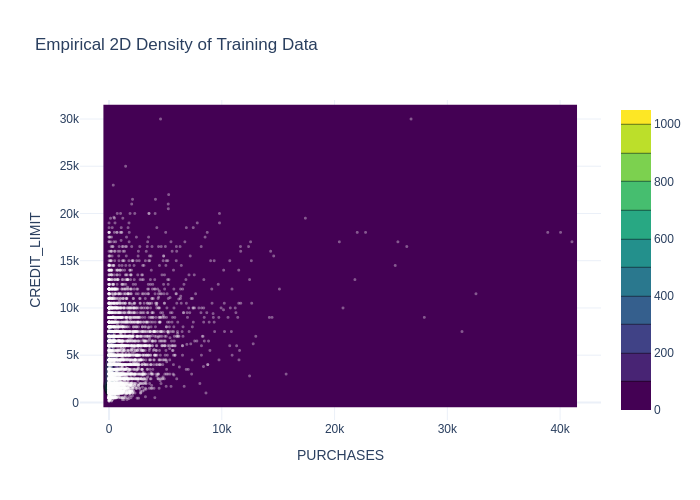

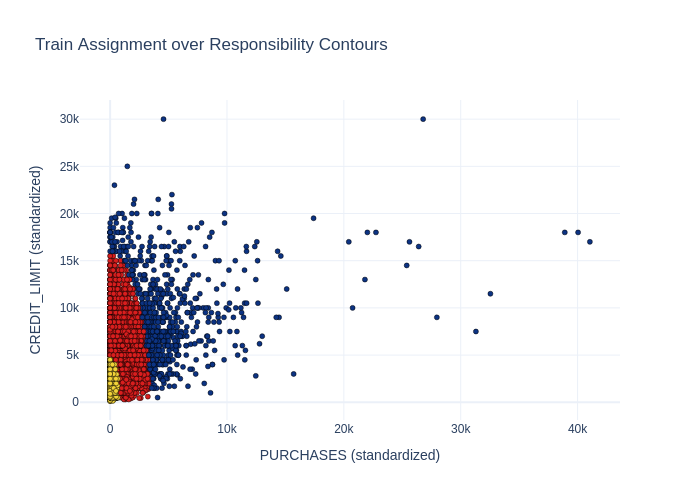

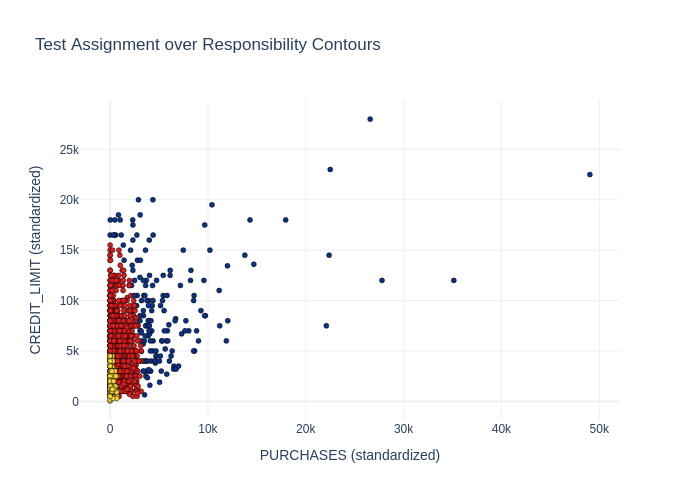

In [14]:
segmenter = GMMFinancialSegmenter(n_components=3, random_state=42, test_size=0.2)
segmenter.fit(df_cc)

fig_density = segmenter.plot_empirical_density()
fig_train_assign = segmenter.plot_assignment(split="train")
fig_test_assign = segmenter.plot_assignment(split="test")

**Evaluation of the plots.** The empirical density heatmap shows three overlapping concentrations of
mass in the (standardized) purchases–credit-limit plane, confirming the multimodal structure the GMM is
meant to recover. The training assignment plot overlays the raw points on a *continuous* filled-contour
background: at every grid location $x_{\text{grid}}$, the background color encodes
$\arg\max_k\gamma_k(x_{\text{grid}})$ where $\gamma_k(x_{\text{grid}})=P(C=k\mid X=x_{\text{grid}})$ is the
component responsibility from `predict_proba`, i.e. exactly the discretized soft-assignment vector
$\mathbb E[Z\mid X=x_{\text{grid}}]$ derived analytically in Part 3 — the plot is a direct visualization of
that conditional expectation evaluated over the whole feature space, not just at the observed data points.
Regions where the contour boundaries sit close together and colors change rapidly are exactly the regions
of high posterior ambiguity (no single $\gamma_k$ dominates); the test assignment plot repeats this same
background but overlays unseen validation points, letting us visually check whether points from unseen
customers still fall predominantly into confident (single-color, non-boundary) regions — a spot check on
how well the fitted density generalizes, consistent with the numerically reported out-of-sample
log-likelihood.

---
## Summary

All four Bayesian-updating problems were solved end to end:

- **Q1 (2PL IRT):** non-conjugate grid-based sequential ability tracking, with full derivations of the
  likelihood, recursive posterior, shift/sharpness behavior, and a converging 20-item simulation.
- **Q2 (CTR):** exact conjugate Beta-Binomial updates with closed-form $\alpha_k,\beta_k$ recursions and a
  100-impression convergence simulation.
- **Q3 (SHM):** non-conjugate log-normal/Beta grid tracking with trapezoidal normalization and a
  15-inspection convergence-and-density-evolution simulation.
- **Q4 (GMM):** full derivation of the mixture density, responsibilities, EM's E/M steps as conditional
  updating, and a working `GMMFinancialSegmenter` class with train/test splitting, convergence diagnostics,
  out-of-sample log-likelihood, and three interactive Plotly visualizations.

In every case the unifying theme is the same: a posterior belief is repeatedly updated by combining a prior
(or previous posterior) with a likelihood via Bayes' theorem — exactly, in closed form, when conjugacy
holds (Q2, and the E-step responsibilities of Q4), and approximately, via discretized numerical integration
on a grid, when it does not (Q1, Q3).